In [1]:
from utils.utils import DataLoader, DopplerDataset, plot_learning_curves
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


🔄 Chargement des données: 100%|██████████| 50/50 [00:01<00:00, 32.93exp/s]


🔔 Starting Regression/BET_ResNet1
✅ Network Initialized
5000


Testing (regression): 100%|██████████| 313/313 [01:51<00:00,  2.80batch/s, mse=0.0634]


📏 Test MSE (moyenne par échantillon): 0.0966
📏 Test MSE (denormalized): 3.6111


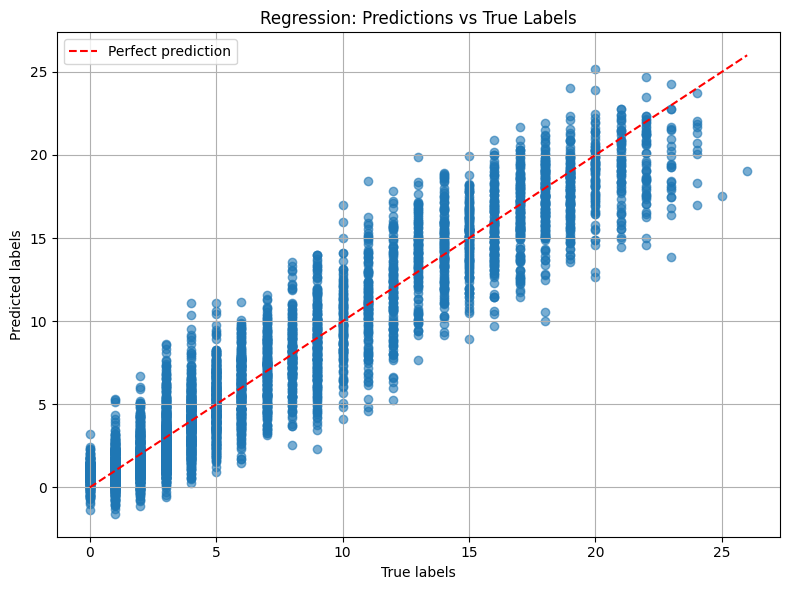

In [3]:
l_exp = [f"Regression/BET_ResNet1"]

data_loader = DataLoader(base_path, exp_list=all)

for exp in l_exp :
    #exp = "DefaultExp"
    print(f"🔔 Starting {exp}")
    stream = open(f"exp_list/{exp}.yaml", 'r')
    param  = yaml.safe_load(stream)
    param["TRAINING"]["DEVICE"] = 'mps'

    resultsPath = os.path.join("results", exp)

    # Create the directory
    if not os.path.exists(resultsPath):
        os.makedirs(resultsPath)

    myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

    # Train the network
    #train_losses, val_losses =  myNetwork.train()

    # Test the network
    myNetwork.loadWeight()
    myNetwork.test()   





In [4]:
print(len(myNetwork.dataSetTrain))
print(len(myNetwork.dataSetTest))
print(len(myNetwork.dataSetVal))

39640
4955
4955


In [ ]:
num_params = sum(p.numel() for p in myNetwork.model.parameters())
print(f"Number of parameters: {num_params}") 
# V1 = 2.147.874.498
# V2 = 8.482.754
# V3 = 2.190.530
# V_reg = 2.190.465
# V_reg_48CH = 12.833.441
# V_reg4 = 8.505.697
# V_reg5 = 3.201.769
# Res Net = 11.175.554

Number of parameters: 11175554


[0.23248756 0.14253994 0.1146355  0.09405757 0.07839283]
[0.14341345 0.18540732 0.13099862 0.09077738 0.09242128]


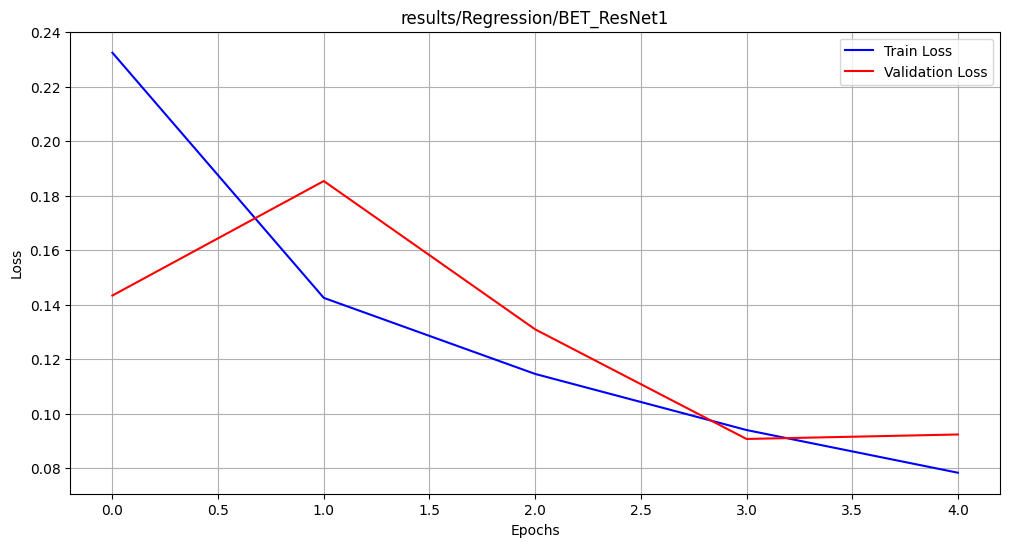

In [4]:
# Load learning curves
train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)
plot_learning_curves(train_losses, val_losses, resultsPath)